In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
SPLIT_DIR = DATA_DIR / "splits" 

residue_path = PROCESSED_DIR / "chi1_residue_level_dataset_full_features.csv"

residue_df = pd.read_csv(residue_path)

residue_df.shape

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_8769/1866716920.py:7: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  residue_df = pd.read_csv(residue_path)


(1165673, 42)

In [3]:
NUM_CLASSES = 36
WINDOW_SIZE = 65
CONTEXT_RADIUS = WINDOW_SIZE // 2

IGNORE_INDEX = -100
PAD_TOKEN = "PAD"
UNK_TOKEN = "UNK"

DISTANCE_NORMALIZATION = 30.0

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='mps')

In [4]:
train_pdb_ids = set(pd.read_csv(SPLIT_DIR / "train_pdb_ids.csv")["pdb_id"])
val_pdb_ids = set(pd.read_csv(SPLIT_DIR / "val_pdb_ids.csv")["pdb_id"])
test_pdb_ids = set(pd.read_csv(SPLIT_DIR / "test_pdb_ids.csv")["pdb_id"])

train_residue_df = residue_df[residue_df["pdb_id"].isin(train_pdb_ids)].copy()
val_residue_df = residue_df[residue_df["pdb_id"].isin(val_pdb_ids)].copy()
test_residue_df = residue_df[residue_df["pdb_id"].isin(test_pdb_ids)].copy()

print(train_residue_df.shape)
print(val_residue_df.shape)
print(test_residue_df.shape)

(929004, 42)
(113997, 42)
(118229, 42)


In [5]:
FEATURE_COLUMNS = [
    "resname",
    "polarity_group",
    "hydropathy_group",
    "volume_group",
    "chemical_group",
    "physicochemical_group",
    "charge_group",
    "hydrogen_donor_acceptor_group",
    "dssp_ss",
]

NUMERIC_COLUMNS = [
    "phi_sin",
    "phi_cos",
    "psi_sin",
    "psi_cos",
    "has_phi",
    "has_psi",

    "ca_cb_x",
    "ca_cb_y",
    "ca_cb_z",
    "has_ca_cb_direction",

    "chain_break_prev",
    "chain_break_next",

    "dssp_asa",
    "dssp_has",
]

In [6]:
cat_to_idx = {}

for col in FEATURE_COLUMNS:
    values = sorted(train_residue_df[col].fillna("UNK").astype(str).unique().tolist())

    vocab = [PAD_TOKEN, UNK_TOKEN]

    for value in values:
        if value not in vocab:
            vocab.append(value)

    cat_to_idx[col] = {value: idx for idx, value in enumerate(vocab)}

for col in FEATURE_COLUMNS:
    print(col, len(cat_to_idx[col]))

resname 22
polarity_group 4
hydropathy_group 5
volume_group 6
chemical_group 13
physicochemical_group 11
charge_group 6
hydrogen_donor_acceptor_group 6
dssp_ss 11


In [7]:
valid_train = train_residue_df[train_residue_df["target_mask"] == 1].copy()

global_counts = np.zeros(NUM_CLASSES, dtype=np.float32)

for bin_id in valid_train["chi1_bin_10deg"].astype(int):
    if 0 <= bin_id < NUM_CLASSES:
        global_counts[bin_id] += 1.0

global_prior = global_counts + 1.0
global_prior = global_prior / global_prior.sum()

aa_prior_dict = {}

for resname, group in valid_train.groupby("resname"):
    counts = np.zeros(NUM_CLASSES, dtype=np.float32)

    for bin_id in group["chi1_bin_10deg"].astype(int):
        if 0 <= bin_id < NUM_CLASSES:
            counts[bin_id] += 1.0

    counts = counts + 1.0
    prior = counts / counts.sum()

    aa_prior_dict[resname] = prior.astype(np.float32)

print("Global prior sum:", global_prior.sum())
print("Number of amino acid priors:", len(aa_prior_dict))

Global prior sum: 1.0
Number of amino acid priors: 18


In [8]:
for aa in ["VAL", "LEU", "ILE", "ARG", "SER"]:
    print(aa, aa_prior_dict.get(aa, global_prior)[:10])

VAL [0.00134011 0.00123229 0.00143253 0.00374307 0.0090573  0.02768022
 0.0362292  0.01700555 0.00651571 0.00261861]
LEU [0.00057372 0.0008797  0.00186139 0.00337855 0.0058519  0.00818502
 0.00808302 0.00586465 0.0033403  0.0017339 ]
ILE [0.00122804 0.00120823 0.00247588 0.00516965 0.01570701 0.04898291
 0.06724504 0.0128746  0.00352566 0.00176283]
ARG [0.00083876 0.00083876 0.0023436  0.00463785 0.01132327 0.02809848
 0.03875567 0.02198046 0.00836294 0.00350306]
SER [0.00218415 0.00245539 0.00485368 0.01016417 0.02576731 0.10004283
 0.15954319 0.06378301 0.01768737 0.00561028]


In [9]:
class LazyChi1WindowDataset(Dataset):
    def __init__(
        self,
        residue_df,
        feature_columns,
        numeric_columns,
        cat_to_idx,
        aa_prior_dict,
        global_prior,
        window_size=65,
        distance_normalization=30.0,
    ):
        self.feature_columns = feature_columns
        self.numeric_columns = numeric_columns
        self.cat_to_idx = cat_to_idx
        self.aa_prior_dict = aa_prior_dict
        self.global_prior = global_prior.astype(np.float32)

        self.window_size = window_size
        self.context_radius = window_size // 2
        self.distance_normalization = distance_normalization

        df = residue_df.copy()

        df["insertion_code"] = (
            df["insertion_code"]
            .fillna("")
            .astype(str)
            .replace("nan", "")
        )

        for col in self.feature_columns:
            df[col] = df[col].fillna("UNK").astype(str)

        for col in self.numeric_columns:
            df[col] = df[col].fillna(0.0).astype(float)

        df = df.sort_values(
            ["pdb_id", "chain_id", "residue_number", "insertion_code"]
        ).reset_index(drop=True)

        self.chains = {}
        self.index = []

        for chain_key, chain_df in df.groupby(["pdb_id", "chain_id"], sort=False):
            chain_df = chain_df.reset_index(drop=True)

            chain_data = {
                "resname": chain_df["resname"].to_numpy(),

                "cat_values": {
                    col: chain_df[col].to_numpy()
                    for col in self.feature_columns
                },

                "numeric": chain_df[self.numeric_columns].to_numpy(dtype=np.float32),

                "targets": chain_df["chi1_bin_10deg"].to_numpy(dtype=np.int64),
                "target_mask": chain_df["target_mask"].to_numpy(dtype=np.bool_),

                "ca_coords": chain_df[["ca_x", "ca_y", "ca_z"]].fillna(0.0).to_numpy(dtype=np.float32),
                "has_ca": chain_df["has_ca"].fillna(0).to_numpy(dtype=np.bool_),
            }

            self.chains[chain_key] = chain_data

            for center_idx in range(len(chain_df)):
                self.index.append((chain_key, center_idx))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        chain_key, center_idx = self.index[idx]
        chain = self.chains[chain_key]

        n = len(chain["targets"])

        x_cat = []
        x_num = []
        aa_priors = []

        y = []
        target_mask = []
        padding_mask = []

        ca_coords = []
        has_ca_mask = []

        for pos in range(center_idx - self.context_radius, center_idx + self.context_radius + 1):
            relative_position = (pos - center_idx) / self.context_radius

            if 0 <= pos < n:
                cat_row = []

                for col in self.feature_columns:
                    value = chain["cat_values"][col][pos]
                    value_idx = self.cat_to_idx[col].get(
                        value,
                        self.cat_to_idx[col][UNK_TOKEN],
                    )
                    cat_row.append(value_idx)

                x_cat.append(cat_row)

                numeric_row = chain["numeric"][pos].tolist()
                numeric_row.append(float(relative_position))
                x_num.append(numeric_row)

                resname = chain["resname"][pos]
                aa_prior = self.aa_prior_dict.get(resname, self.global_prior)
                aa_priors.append(aa_prior)

                y.append(int(chain["targets"][pos]))
                target_mask.append(bool(chain["target_mask"][pos]))
                padding_mask.append(False)

                if chain["has_ca"][pos]:
                    ca_coords.append(chain["ca_coords"][pos])
                    has_ca_mask.append(True)
                else:
                    ca_coords.append(np.array([0.0, 0.0, 0.0], dtype=np.float32))
                    has_ca_mask.append(False)

            else:
                x_cat.append([
                    self.cat_to_idx[col][PAD_TOKEN]
                    for col in self.feature_columns
                ])

                x_num.append([0.0] * len(self.numeric_columns) + [float(relative_position)])
                aa_priors.append(self.global_prior)

                y.append(IGNORE_INDEX)
                target_mask.append(False)
                padding_mask.append(True)

                ca_coords.append(np.array([0.0, 0.0, 0.0], dtype=np.float32))
                has_ca_mask.append(False)

        ca_coords = np.stack(ca_coords).astype(np.float32)
        has_ca_mask = np.array(has_ca_mask, dtype=bool)

        diff = ca_coords[:, None, :] - ca_coords[None, :, :]
        distance_matrix = np.linalg.norm(diff, axis=-1).astype(np.float32)

        distance_matrix = np.minimum(
            distance_matrix / self.distance_normalization,
            1.0,
        )

        invalid_pair_mask = ~(has_ca_mask[:, None] & has_ca_mask[None, :])
        distance_matrix[invalid_pair_mask] = 1.0

        return {
            "x_cat": torch.tensor(x_cat, dtype=torch.long),
            "x_num": torch.tensor(x_num, dtype=torch.float32),
            "distance_matrix": torch.tensor(distance_matrix, dtype=torch.float32),
            "aa_prior": torch.tensor(np.stack(aa_priors), dtype=torch.float32),
            "y": torch.tensor(y, dtype=torch.long),
            "target_mask": torch.tensor(target_mask, dtype=torch.bool),
            "padding_mask": torch.tensor(padding_mask, dtype=torch.bool),
        }

In [10]:
train_dataset = LazyChi1WindowDataset(
    residue_df=train_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    aa_prior_dict=aa_prior_dict,
    global_prior=global_prior,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

val_dataset = LazyChi1WindowDataset(
    residue_df=val_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    aa_prior_dict=aa_prior_dict,
    global_prior=global_prior,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

test_dataset = LazyChi1WindowDataset(
    residue_df=test_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    aa_prior_dict=aa_prior_dict,
    global_prior=global_prior,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

929004
113997
118229


In [11]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [12]:
def circular_bin_distance(pred_bins, true_bins, num_bins=36):
    diff = torch.abs(pred_bins - true_bins)
    return torch.minimum(diff, num_bins - diff)

In [13]:
class DistanceAwareEncoderLayer(nn.Module):
    def __init__(
        self,
        d_model=128,
        nhead=8,
        dim_feedforward=256,
        dropout=0.1,
    ):
        super().__init__()

        self.d_model = d_model
        self.nhead = nhead

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )

        self.distance_bias = nn.Linear(1, nhead)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )

    def forward(self, x, distance_matrix, padding_mask=None):
        batch_size, seq_len, _ = x.shape

        residual = x
        x_norm = self.norm1(x)

        distance_input = distance_matrix.unsqueeze(-1)
        distance_bias = self.distance_bias(distance_input)

        distance_bias = distance_bias.permute(0, 3, 1, 2)
        distance_bias = distance_bias.reshape(
            batch_size * self.nhead,
            seq_len,
            seq_len,
        )

        attn_output, _ = self.self_attn(
            query=x_norm,
            key=x_norm,
            value=x_norm,
            attn_mask=distance_bias,
            key_padding_mask=padding_mask,
            need_weights=False,
        )

        x = residual + self.dropout1(attn_output)

        residual = x
        x_norm = self.norm2(x)
        x = residual + self.dropout2(self.ffn(x_norm))

        return x

In [14]:
class Chi1FullFeatureTransformer(nn.Module):
    def __init__(
        self,
        cat_vocab_sizes,
        cat_embedding_dims,
        num_numeric_features,
        window_size=65,
        d_model=128,
        nhead=8,
        num_layers=4,
        dim_feedforward=256,
        dropout=0.1,
        num_classes=36,
        use_distance_bias=True,
    ):
        super().__init__()

        self.window_size = window_size
        self.use_distance_bias = use_distance_bias

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=emb_dim,
                padding_idx=0,
            )
            for vocab_size, emb_dim in zip(cat_vocab_sizes, cat_embedding_dims)
        ])

        total_cat_dim = sum(cat_embedding_dims)

        self.cat_projection = nn.Sequential(
            nn.Linear(total_cat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.num_projection = nn.Sequential(
            nn.Linear(num_numeric_features, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.prior_projection = nn.Sequential(
            nn.Linear(num_classes, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.input_fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.position_embedding = nn.Embedding(window_size, d_model)

        if use_distance_bias:
            self.layers = nn.ModuleList([
                DistanceAwareEncoderLayer(
                    d_model=d_model,
                    nhead=nhead,
                    dim_feedforward=dim_feedforward,
                    dropout=dropout,
                )
                for _ in range(num_layers)
            ])
        else:
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )

            self.encoder = nn.TransformerEncoder(
                encoder_layer=encoder_layer,
                num_layers=num_layers,
            )

        self.final_norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x_cat, x_num, distance_matrix, aa_prior, padding_mask=None):
        batch_size, seq_len, _ = x_cat.shape

        embedded_features = []

        for feature_idx, embedding_layer in enumerate(self.cat_embeddings):
            feature_values = x_cat[:, :, feature_idx]
            feature_emb = embedding_layer(feature_values)
            embedded_features.append(feature_emb)

        x_cat_emb = torch.cat(embedded_features, dim=-1)
        x_cat_hidden = self.cat_projection(x_cat_emb)

        x_num_hidden = self.num_projection(x_num)

        prior_hidden = self.prior_projection(aa_prior)

        x = torch.cat([x_cat_hidden, x_num_hidden, prior_hidden], dim=-1)
        x = self.input_fusion(x)

        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        x = x + self.position_embedding(positions)

        if self.use_distance_bias:
            for layer in self.layers:
                x = layer(
                    x=x,
                    distance_matrix=distance_matrix,
                    padding_mask=padding_mask,
                )
        else:
            x = self.encoder(
                x,
                src_key_padding_mask=padding_mask,
            )

        x = self.final_norm(x)

        logits = self.classifier(x)

        return logits

In [15]:
cat_vocab_sizes = [len(cat_to_idx[col]) for col in FEATURE_COLUMNS]

cat_embedding_dims = [
    min(32, max(4, vocab_size // 2))
    for vocab_size in cat_vocab_sizes
]

num_numeric_features = len(NUMERIC_COLUMNS) + 1

print("Vocab sizes:", cat_vocab_sizes)
print("Embedding dims:", cat_embedding_dims)
print("Numeric features:", num_numeric_features)

Vocab sizes: [22, 4, 5, 6, 13, 11, 6, 6, 11]
Embedding dims: [11, 4, 4, 4, 6, 5, 4, 4, 5]
Numeric features: 15


In [16]:
model = Chi1FullFeatureTransformer(
    cat_vocab_sizes=cat_vocab_sizes,
    cat_embedding_dims=cat_embedding_dims,
    num_numeric_features=num_numeric_features,
    window_size=WINDOW_SIZE,
    d_model=128,
    nhead=8,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.12,
    num_classes=NUM_CLASSES,
    use_distance_bias=True,
).to(device)

In [17]:
batch = next(iter(train_loader))

x_cat = batch["x_cat"].to(device)
x_num = batch["x_num"].to(device)
distance_matrix = batch["distance_matrix"].to(device)
aa_prior = batch["aa_prior"].to(device)
padding_mask = batch["padding_mask"].to(device)

with torch.no_grad():
    logits = model(
        x_cat=x_cat,
        x_num=x_num,
        distance_matrix=distance_matrix,
        aa_prior=aa_prior,
        padding_mask=padding_mask,
    )

print(logits.shape)

torch.Size([128, 65, 36])


/opt/anaconda3/lib/python3.12/site-packages/torch/nn/functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


In [18]:
def train_one_epoch_full(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for batch in progress_bar:
        x_cat = batch["x_cat"].to(device)
        x_num = batch["x_num"].to(device)
        distance_matrix = batch["distance_matrix"].to(device)
        aa_prior = batch["aa_prior"].to(device)

        y = batch["y"].to(device)
        target_mask = batch["target_mask"].to(device)
        padding_mask = batch["padding_mask"].to(device)

        optimizer.zero_grad()

        logits = model(
            x_cat=x_cat,
            x_num=x_num,
            distance_matrix=distance_matrix,
            aa_prior=aa_prior,
            padding_mask=padding_mask,
        )

        loss = criterion(
            logits.reshape(-1, NUM_CLASSES),
            y.reshape(-1),
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        with torch.no_grad():
            pred_bins = torch.argmax(logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    return {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

In [20]:
def evaluate_full(model, loader, criterion, device, desc="Validation"):
    model.eval()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc=desc, leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            x_cat = batch["x_cat"].to(device)
            x_num = batch["x_num"].to(device)
            distance_matrix = batch["distance_matrix"].to(device)
            aa_prior = batch["aa_prior"].to(device)

            y = batch["y"].to(device)
            target_mask = batch["target_mask"].to(device)
            padding_mask = batch["padding_mask"].to(device)

            logits = model(
                x_cat=x_cat,
                x_num=x_num,
                distance_matrix=distance_matrix,
                aa_prior=aa_prior,
                padding_mask=padding_mask,
            )

            loss = criterion(
                logits.reshape(-1, NUM_CLASSES),
                y.reshape(-1),
            )

            pred_bins = torch.argmax(logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    return {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

In [21]:
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1.5e-4,
    weight_decay=1e-4,
)

NUM_EPOCHS = 15

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6,
)

history = []

best_val_acc_pm3 = -1.0
best_model_path = PROCESSED_DIR / "best_chi1_full_feature_transformer.pt"

In [22]:
for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs"):
    train_metrics = train_one_epoch_full(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_metrics = evaluate_full(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        desc="Validation",
    )

    scheduler.step()

    row = {
        "epoch": epoch,
        "lr": scheduler.get_last_lr()[0],
        "train_loss": train_metrics["loss"],
        "train_acc_exact": train_metrics["acc_exact"],
        "train_acc_pm1": train_metrics["acc_pm1"],
        "train_acc_pm3": train_metrics["acc_pm3"],
        "train_mean_circular_distance": train_metrics["mean_circular_distance"],
        "val_loss": val_metrics["loss"],
        "val_acc_exact": val_metrics["acc_exact"],
        "val_acc_pm1": val_metrics["acc_pm1"],
        "val_acc_pm3": val_metrics["acc_pm3"],
        "val_mean_circular_distance": val_metrics["mean_circular_distance"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train acc@±3 {train_metrics['acc_pm3']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"val acc@±3 {val_metrics['acc_pm3']:.4f} | "
        f"val exact {val_metrics['acc_exact']:.4f}"
    )

    if val_metrics["acc_pm3"] > best_val_acc_pm3:
        best_val_acc_pm3 = val_metrics["acc_pm3"]

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "cat_to_idx": cat_to_idx,
                "feature_columns": FEATURE_COLUMNS,
                "numeric_columns": NUMERIC_COLUMNS,
                "cat_vocab_sizes": cat_vocab_sizes,
                "cat_embedding_dims": cat_embedding_dims,
                "num_numeric_features": num_numeric_features,
                "best_val_acc_pm3": best_val_acc_pm3,
                "epoch": epoch,
            },
            best_model_path,
        )

        print(f"Saved best model to {best_model_path}")

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Training:   0%|          | 0/7258 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 01 | train loss 2.2600 | train acc@±3 0.6566 | val loss 2.1141 | val acc@±3 0.6838 | val exact 0.3380
Saved best model to data/processed/best_chi1_full_feature_transformer.pt


...

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 14 | train loss 1.9641 | train acc@±3 0.7199 | val loss 1.9661 | val acc@±3 0.7225 | val exact 0.3736


Training:   0%|          | 0/7258 [00:00<?, ?it/s]

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 15 | train loss 1.9633 | train acc@±3 0.7201 | val loss 1.9651 | val acc@±3 0.7225 | val exact 0.3737
Saved best model to data/processed/best_chi1_full_feature_transformer.pt


In [23]:
history_df = pd.DataFrame(history)
history_df

,epoch,lr,train_loss,train_acc_exact,train_acc_pm1,train_acc_pm3,train_mean_circular_distance,val_loss,val_acc_exact,val_acc_pm1,val_acc_pm3,val_mean_circular_distance
0,1,0.000148,2.260008,0.298657,0.557533,0.656592,4.169215,2.114128,0.337987,0.588522,0.683846,3.854753
1,2,0.000144,2.133654,0.328082,0.585156,0.682238,3.866142,2.048636,0.351711,0.604213,0.698798,3.662059
2,3,0.000136,2.079976,0.339970,0.599260,0.695236,3.716412,2.007784,0.362909,0.618508,0.710957,3.528946
3,4,0.000125,2.045795,0.347788,0.608181,0.703097,3.628513,1.987347,0.367079,0.623033,0.714852,3.489916
4,5,0.000113,2.023903,0.352422,0.613428,0.707726,3.577640,1.978787,0.369520,0.625795,0.717101,3.468277
5,6,0.000099,2.008153,0.355712,0.617018,0.710925,3.542400,1.975752,0.371011,0.627007,0.719268,3.439858
6,7,0.000083,1.996262,0.358096,0.619671,0.713335,3.516140,1.972038,0.371502,0.628124,0.720043,3.433973
7,8,0.000068,1.986922,0.359985,0.621850,0.715282,3.494780,1.970442,0.372642,0.629106,0.720763,3.427271
8,9,0.000052,1.979819,0.361411,0.623378,0.716698,3.479128,1.967715,0.372676,0.629943,0.721468,3.422662
9,10,0.000038,1.974298,0.362464,0.624672,0.717870,3.466136,1.968000,0.373190,0.630700,0.722076,3.415882


In [24]:
history_path = PROCESSED_DIR / "training_history_chi1_full_feature_transformer.csv"
history_df.to_csv(history_path, index=False)

print("Saved history:", history_path)

Saved history: data/processed/training_history_chi1_full_feature_transformer.csv


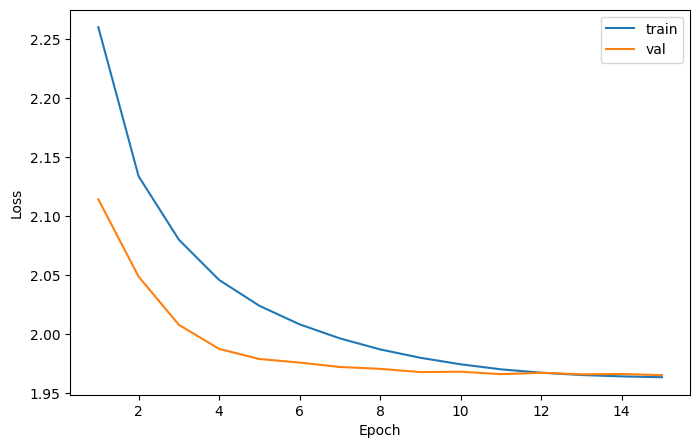

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

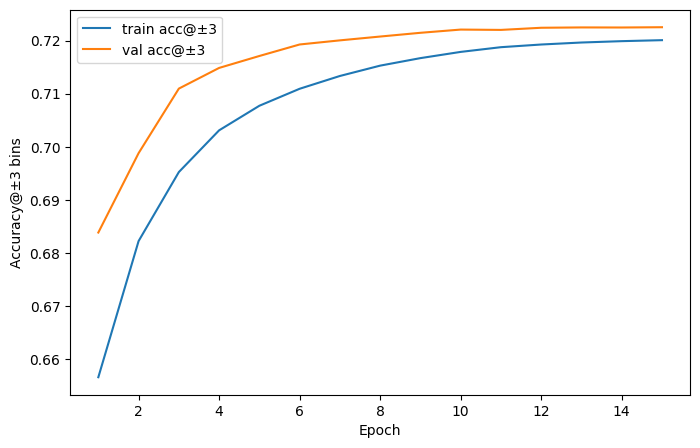

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc_pm3"], label="train acc@±3")
plt.plot(history_df["epoch"], history_df["val_acc_pm3"], label="val acc@±3")
plt.xlabel("Epoch")
plt.ylabel("Accuracy@±3 bins")
plt.legend()
plt.show()

In [16]:
RESNAME_FEATURE_INDEX = FEATURE_COLUMNS.index("resname")

print("resname feature index:", RESNAME_FEATURE_INDEX)
print("resname vocab:", cat_to_idx["resname"])

resname feature index: 0
resname vocab: {'PAD': 0, 'UNK': 1, 'ALA': 2, 'ARG': 3, 'ASN': 4, 'ASP': 5, 'CYS': 6, 'GLN': 7, 'GLU': 8, 'GLY': 9, 'HIS': 10, 'ILE': 11, 'LEU': 12, 'LYS': 13, 'MET': 14, 'PHE': 15, 'PRO': 16, 'SER': 17, 'THR': 18, 'TRP': 19, 'TYR': 20, 'VAL': 21}


In [17]:
AA_HEAD_NAMES = [
    "ARG", "ASN", "ASP", "CYS", "GLN",
    "GLU", "HIS", "ILE", "LEU", "LYS",
    "MET", "PHE", "PRO", "SER", "THR",
    "TRP", "TYR", "VAL",
]

In [18]:
aa_name_to_head_idx = {
    aa: i
    for i, aa in enumerate(AA_HEAD_NAMES)
}

aa_token_idx_to_head_idx = {}

for aa_name, token_idx in cat_to_idx["resname"].items():
    if aa_name in aa_name_to_head_idx:
        aa_token_idx_to_head_idx[token_idx] = aa_name_to_head_idx[aa_name]

aa_token_idx_to_head_idx

{3: 0,
 4: 1,
 5: 2,
 6: 3,
 7: 4,
 8: 5,
 10: 6,
 11: 7,
 12: 8,
 13: 9,
 14: 10,
 15: 11,
 16: 12,
 17: 13,
 18: 14,
 19: 15,
 20: 16,
 21: 17}

In [19]:
num_resname_tokens = len(cat_to_idx["resname"])

resname_to_head = torch.full(
    size=(num_resname_tokens,),
    fill_value=-1,
    dtype=torch.long,
)

for token_idx, head_idx in aa_token_idx_to_head_idx.items():
    resname_to_head[token_idx] = head_idx

resname_to_head

tensor([-1, -1, -1,  0,  1,  2,  3,  4,  5, -1,  6,  7,  8,  9, 10, 11, 12, 13,
        14, 15, 16, 17])

In [20]:
class DistanceAwareEncoderLayer(nn.Module):
    def __init__(
        self,
        d_model=128,
        nhead=8,
        dim_feedforward=256,
        dropout=0.1,
    ):
        super().__init__()

        self.d_model = d_model
        self.nhead = nhead

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )

        self.distance_bias = nn.Linear(1, nhead)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )

    def forward(self, x, distance_matrix, padding_mask=None):
        batch_size, seq_len, _ = x.shape

        residual = x
        x_norm = self.norm1(x)

        distance_input = distance_matrix.unsqueeze(-1)
        distance_bias = self.distance_bias(distance_input)

        distance_bias = distance_bias.permute(0, 3, 1, 2)
        distance_bias = distance_bias.reshape(
            batch_size * self.nhead,
            seq_len,
            seq_len,
        )

        attn_output, _ = self.self_attn(
            query=x_norm,
            key=x_norm,
            value=x_norm,
            attn_mask=distance_bias,
            key_padding_mask=padding_mask,
            need_weights=False,
        )

        x = residual + self.dropout1(attn_output)

        residual = x
        x_norm = self.norm2(x)
        x = residual + self.dropout2(self.ffn(x_norm))

        return x

In [21]:
class Chi1FullFeatureTransformerWithAAHeads(nn.Module):
    def __init__(
        self,
        cat_vocab_sizes,
        cat_embedding_dims,
        num_numeric_features,
        resname_to_head,
        resname_feature_index,
        num_aa_heads,
        window_size=65,
        d_model=128,
        nhead=8,
        num_layers=4,
        dim_feedforward=256,
        dropout=0.1,
        num_classes=36,
        use_distance_bias=True,
    ):
        super().__init__()

        self.window_size = window_size
        self.use_distance_bias = use_distance_bias
        self.resname_feature_index = resname_feature_index
        self.num_aa_heads = num_aa_heads
        self.num_classes = num_classes

        self.register_buffer("resname_to_head", resname_to_head.clone())

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=emb_dim,
                padding_idx=0,
            )
            for vocab_size, emb_dim in zip(cat_vocab_sizes, cat_embedding_dims)
        ])

        total_cat_dim = sum(cat_embedding_dims)

        self.cat_projection = nn.Sequential(
            nn.Linear(total_cat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.num_projection = nn.Sequential(
            nn.Linear(num_numeric_features, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.prior_projection = nn.Sequential(
            nn.Linear(num_classes, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.input_fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.position_embedding = nn.Embedding(window_size, d_model)

        if use_distance_bias:
            self.layers = nn.ModuleList([
                DistanceAwareEncoderLayer(
                    d_model=d_model,
                    nhead=nhead,
                    dim_feedforward=dim_feedforward,
                    dropout=dropout,
                )
                for _ in range(num_layers)
            ])
        else:
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )

            self.encoder = nn.TransformerEncoder(
                encoder_layer=encoder_layer,
                num_layers=num_layers,
            )

        self.final_norm = nn.LayerNorm(d_model)

        self.shared_classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

        self.aa_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model, d_model),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model, num_classes),
            )
            for _ in range(num_aa_heads)
        ])

    def encode(self, x_cat, x_num, distance_matrix, aa_prior, padding_mask=None):
        batch_size, seq_len, _ = x_cat.shape

        embedded_features = []

        for feature_idx, embedding_layer in enumerate(self.cat_embeddings):
            feature_values = x_cat[:, :, feature_idx]
            feature_emb = embedding_layer(feature_values)
            embedded_features.append(feature_emb)

        x_cat_emb = torch.cat(embedded_features, dim=-1)
        x_cat_hidden = self.cat_projection(x_cat_emb)

        x_num_hidden = self.num_projection(x_num)
        prior_hidden = self.prior_projection(aa_prior)

        x = torch.cat([x_cat_hidden, x_num_hidden, prior_hidden], dim=-1)
        x = self.input_fusion(x)

        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        x = x + self.position_embedding(positions)

        if self.use_distance_bias:
            for layer in self.layers:
                x = layer(
                    x=x,
                    distance_matrix=distance_matrix,
                    padding_mask=padding_mask,
                )
        else:
            x = self.encoder(
                x,
                src_key_padding_mask=padding_mask,
            )

        x = self.final_norm(x)

        return x

    def forward(self, x_cat, x_num, distance_matrix, aa_prior, padding_mask=None):
        hidden = self.encode(
            x_cat=x_cat,
            x_num=x_num,
            distance_matrix=distance_matrix,
            aa_prior=aa_prior,
            padding_mask=padding_mask,
        )

        logits = self.shared_classifier(hidden)

        resname_token_ids = x_cat[:, :, self.resname_feature_index]
        head_ids = self.resname_to_head[resname_token_ids]

        flat_hidden = hidden.reshape(-1, hidden.shape[-1])
        flat_logits = logits.reshape(-1, self.num_classes)
        flat_head_ids = head_ids.reshape(-1)

        for head_idx, head in enumerate(self.aa_heads):
            mask = flat_head_ids == head_idx

            if mask.any():
                flat_logits[mask] = head(flat_hidden[mask])

        logits = flat_logits.reshape_as(logits)

        return logits

In [22]:
cat_vocab_sizes = [len(cat_to_idx[col]) for col in FEATURE_COLUMNS]

cat_embedding_dims = [
    min(32, max(4, vocab_size // 2))
    for vocab_size in cat_vocab_sizes
]

num_numeric_features = len(NUMERIC_COLUMNS) + 1

print("Vocab sizes:", cat_vocab_sizes)
print("Embedding dims:", cat_embedding_dims)
print("Numeric features:", num_numeric_features)
print("AA heads:", len(AA_HEAD_NAMES))

Vocab sizes: [22, 4, 5, 6, 13, 11, 6, 6, 11]
Embedding dims: [11, 4, 4, 4, 6, 5, 4, 4, 5]
Numeric features: 15
AA heads: 18


In [23]:
model = Chi1FullFeatureTransformerWithAAHeads(
    cat_vocab_sizes=cat_vocab_sizes,
    cat_embedding_dims=cat_embedding_dims,
    num_numeric_features=num_numeric_features,
    resname_to_head=resname_to_head,
    resname_feature_index=RESNAME_FEATURE_INDEX,
    num_aa_heads=len(AA_HEAD_NAMES),
    window_size=WINDOW_SIZE,
    d_model=160,
    nhead=8,
    num_layers=5,
    dim_feedforward=320,
    dropout=0.12,
    num_classes=NUM_CLASSES,
    use_distance_bias=True,
).to(device)

In [24]:
batch = next(iter(train_loader))

x_cat = batch["x_cat"].to(device)
x_num = batch["x_num"].to(device)
distance_matrix = batch["distance_matrix"].to(device)
aa_prior = batch["aa_prior"].to(device)
padding_mask = batch["padding_mask"].to(device)

with torch.no_grad():
    logits = model(
        x_cat=x_cat,
        x_num=x_num,
        distance_matrix=distance_matrix,
        aa_prior=aa_prior,
        padding_mask=padding_mask,
    )

print(logits.shape)

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


torch.Size([128, 65, 36])


In [25]:
def circular_bin_distance(pred_bins, true_bins, num_bins=36):
    diff = torch.abs(pred_bins - true_bins)
    return torch.minimum(diff, num_bins - diff)

In [26]:
def train_one_epoch_full(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for batch in progress_bar:
        x_cat = batch["x_cat"].to(device)
        x_num = batch["x_num"].to(device)
        distance_matrix = batch["distance_matrix"].to(device)
        aa_prior = batch["aa_prior"].to(device)

        y = batch["y"].to(device)
        target_mask = batch["target_mask"].to(device)
        padding_mask = batch["padding_mask"].to(device)

        optimizer.zero_grad()

        logits = model(
            x_cat=x_cat,
            x_num=x_num,
            distance_matrix=distance_matrix,
            aa_prior=aa_prior,
            padding_mask=padding_mask,
        )

        loss = criterion(
            logits.reshape(-1, NUM_CLASSES),
            y.reshape(-1),
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            pred_bins = torch.argmax(logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    return {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

In [27]:
def evaluate_full(model, loader, criterion, device, desc="Validation"):
    model.eval()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc=desc, leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            x_cat = batch["x_cat"].to(device)
            x_num = batch["x_num"].to(device)
            distance_matrix = batch["distance_matrix"].to(device)
            aa_prior = batch["aa_prior"].to(device)

            y = batch["y"].to(device)
            target_mask = batch["target_mask"].to(device)
            padding_mask = batch["padding_mask"].to(device)

            logits = model(
                x_cat=x_cat,
                x_num=x_num,
                distance_matrix=distance_matrix,
                aa_prior=aa_prior,
                padding_mask=padding_mask,
            )

            loss = criterion(
                logits.reshape(-1, NUM_CLASSES),
                y.reshape(-1),
            )

            pred_bins = torch.argmax(logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    return {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

In [28]:
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1.2e-4,
    weight_decay=2e-4,
)
NUM_EPOCHS = 20

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6,
)

history = []

best_val_acc_pm3 = -1.0
best_model_path = PROCESSED_DIR / "best_chi1_full_feature_aa_heads_transformer.pt"

In [29]:
for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs"):
    train_metrics = train_one_epoch_full(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_metrics = evaluate_full(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        desc="Validation",
    )

    scheduler.step()

    row = {
        "epoch": epoch,
        "lr": scheduler.get_last_lr()[0],
        "train_loss": train_metrics["loss"],
        "train_acc_exact": train_metrics["acc_exact"],
        "train_acc_pm1": train_metrics["acc_pm1"],
        "train_acc_pm3": train_metrics["acc_pm3"],
        "train_mean_circular_distance": train_metrics["mean_circular_distance"],
        "val_loss": val_metrics["loss"],
        "val_acc_exact": val_metrics["acc_exact"],
        "val_acc_pm1": val_metrics["acc_pm1"],
        "val_acc_pm3": val_metrics["acc_pm3"],
        "val_mean_circular_distance": val_metrics["mean_circular_distance"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train acc@±3 {train_metrics['acc_pm3']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"val acc@±3 {val_metrics['acc_pm3']:.4f} | "
        f"val exact {val_metrics['acc_exact']:.4f}"
    )

    if val_metrics["acc_pm3"] > best_val_acc_pm3:
        best_val_acc_pm3 = val_metrics["acc_pm3"]

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "cat_to_idx": cat_to_idx,
                "feature_columns": FEATURE_COLUMNS,
                "numeric_columns": NUMERIC_COLUMNS,
                "cat_vocab_sizes": cat_vocab_sizes,
                "cat_embedding_dims": cat_embedding_dims,
                "num_numeric_features": num_numeric_features,
                "aa_head_names": AA_HEAD_NAMES,
                "resname_to_head": resname_to_head.cpu(),
                "best_val_acc_pm3": best_val_acc_pm3,
                "epoch": epoch,
            },
            best_model_path,
        )

        print(f"Saved best model to {best_model_path}")

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/7258 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 01 | train loss 2.2108 | train acc@±3 0.6634 | val loss 2.0835 | val acc@±3 0.6869 | val exact 0.3446
Saved best model to data/processed/best_chi1_full_feature_aa_heads_transformer.pt


...

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 19 | train loss 1.6240 | train acc@±3 0.7614 | val loss 2.1489 | val acc@±3 0.7124 | val exact 0.3656


Training:   0%|          | 0/7258 [00:00<?, ?it/s]

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 20 | train loss 1.6230 | train acc@±3 0.7615 | val loss 2.1495 | val acc@±3 0.7125 | val exact 0.3657


In [30]:
history_df = pd.DataFrame(history)
history_df

,epoch,lr,train_loss,train_acc_exact,train_acc_pm1,train_acc_pm3,train_mean_circular_distance,val_loss,val_acc_exact,val_acc_pm1,val_acc_pm3,val_mean_circular_distance
0,1,0.000119,2.210805,0.310906,0.564212,0.663400,4.086195,2.083494,0.344589,0.591875,0.686885,3.812382
1,2,0.000117,2.071325,0.342572,0.593109,0.689388,3.779323,2.033260,0.354763,0.602685,0.697756,3.672902
2,3,0.000114,1.995740,0.360125,0.609214,0.704475,3.605312,2.013436,0.362296,0.611701,0.707663,3.562705
3,4,0.000109,1.929753,0.375724,0.621864,0.716089,3.471095,2.007783,0.366518,0.617038,0.711825,3.521528
4,5,0.000103,1.872815,0.389510,0.632038,0.725303,3.362950,2.021093,0.367545,0.618366,0.714086,3.499641
5,6,0.000095,1.823817,0.401729,0.640609,0.732760,3.274137,2.036771,0.366808,0.617157,0.713858,3.501562
6,7,0.000088,1.783025,0.412074,0.647679,0.738733,3.202076,2.053768,0.366750,0.617677,0.714219,3.497307
7,8,0.000079,1.749529,0.420818,0.653451,0.743508,3.144300,2.074769,0.367170,0.617581,0.714046,3.497167
8,9,0.000070,1.722034,0.428016,0.658223,0.747478,3.096337,2.088121,0.366572,0.616493,0.714044,3.494669
9,10,0.000061,1.699513,0.434011,0.662143,0.750625,3.057893,2.105396,0.366777,0.616752,0.714282,3.492686


In [31]:
history_path = PROCESSED_DIR / "training_history_chi1_full_feature_aa_heads_transformer.csv"
history_df.to_csv(history_path, index=False)

print("Saved history:", history_path)

Saved history: data/processed/training_history_chi1_full_feature_aa_heads_transformer.csv


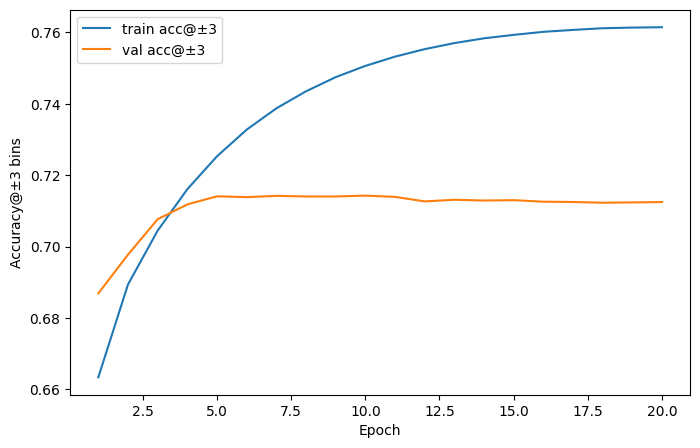

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc_pm3"], label="train acc@±3")
plt.plot(history_df["epoch"], history_df["val_acc_pm3"], label="val acc@±3")
plt.xlabel("Epoch")
plt.ylabel("Accuracy@±3 bins")
plt.legend()
plt.show()

In [ ]:
###